# Customer Retention and Churn Analysis

# The objective of this project is to evaluate customer behavior, identify key churn drivers, and map out customer lifecycle patterns using descriptive analytics and behavioral feature engineering. 
# This analysis helps segment customers by contract risk, billing automation, and ecosystem engagement to formulate targeted retention strategies for business growth.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Data Understanding

print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.isna().sum(), '\n')
print(df.duplicated().sum(), '\n')

(7043, 21) 

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMe

In [4]:
print(list(df.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
print([df['tenure'].min(), df['tenure'].max()])
print(df['PaymentMethod'].unique())
print([df['MonthlyCharges'].min(), df['MonthlyCharges'].max()])
print([df['TotalCharges'].min(), df['TotalCharges'].max()])

[0, 72]
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
[18.25, 118.75]
[' ', '999.9']


In [6]:
# Data Cleaning

features = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
           'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
for col in features:
    df[col] = df[col].apply(lambda x : 1 if x=='Yes' else 0)

In [7]:
# Feature Engineering

df['TenureGroup'] = df['tenure'].apply(lambda x : 'short-term' if x <= 12 else ('mid-term' if x <= 48 else 'long-term'))
df['IsAutomatic'] = df['PaymentMethod'].apply(lambda x : 1 if x in ['Bank transfer (automatic)', 'Credit card (automatic)'] else 0)

print(df[['tenure', 'TenureGroup']], '\n\n')
print(df[['PaymentMethod', 'IsAutomatic']], '\n\n')

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumberOfServices'] = df[service_cols].sum(axis=1)
print(df[service_cols + ['NumberOfServices']])

      tenure TenureGroup
0          1  short-term
1         34    mid-term
2          2  short-term
3         45    mid-term
4          2  short-term
...      ...         ...
7038      24    mid-term
7039      72   long-term
7040      11  short-term
7041       4  short-term
7042      66   long-term

[7043 rows x 2 columns] 


                  PaymentMethod  IsAutomatic
0              Electronic check            0
1                  Mailed check            0
2                  Mailed check            0
3     Bank transfer (automatic)            1
4              Electronic check            0
...                         ...          ...
7038               Mailed check            0
7039    Credit card (automatic)            1
7040           Electronic check            0
7041               Mailed check            0
7042  Bank transfer (automatic)            1

[7043 rows x 2 columns] 


      OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0                  0             1 

In [8]:
df = df.dropna(subset=['TotalCharges'])

total_customers = len(df)
churned_customers = df['Churn'].sum()
retained_customers = total_customers - churned_customers

base_churn_ratio = churned_customers / total_customers
base_churn_percentage = base_churn_ratio * 100
customer_retention_percentage = (1 - base_churn_ratio) * 100

print('Total Customers          : ', total_customers)
print('Churned Customers        : ', churned_customers)
print('Retained Customers       : ', retained_customers)
print(f"Base Churn Rate         : {base_churn_percentage:.2f}%")
print(f"Customer Retention Rate : {customer_retention_percentage:.2f}%")

Total Customers          :  7032
Churned Customers        :  1869
Retained Customers       :  5163
Base Churn Rate         : 26.58%
Customer Retention Rate : 73.42%


In [9]:
numeric_cols = df.select_dtypes(include='number')
churn_correlation = numeric_cols.corr()['Churn'].sort_values(ascending=False)
print(churn_correlation)

# positive correlation indicates they are the cause for churn to increase
# negative correlation indicates they do not increase churn 

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
StreamingTV         0.063254
StreamingMovies     0.060860
PhoneService        0.011691
DeviceProtection   -0.066193
OnlineBackup       -0.082307
NumberOfServices   -0.087882
Partner            -0.149982
Dependents         -0.163128
TechSupport        -0.164716
OnlineSecurity     -0.171270
TotalCharges       -0.199484
IsAutomatic        -0.210420
tenure             -0.354049
Name: Churn, dtype: float64


In [10]:
cohort_analysis = df.groupby('TenureGroup')['Churn'].agg(['count','sum']).reset_index()
cohort_analysis.columns = ['TenureGroup', 'TotalCustomers', 'ChurnedCustomers']

cohort_analysis['ChurnRate'] = (cohort_analysis['ChurnedCustomers']/cohort_analysis['TotalCustomers'])*100
cohort_analysis['RetentionRate'] = 100 - cohort_analysis['ChurnRate']

print(cohort_analysis, '\n')

  TenureGroup  TotalCustomers  ChurnedCustomers  ChurnRate  RetentionRate
0   long-term            2239               213   9.513176      90.486824
1    mid-term            2618               619  23.644003      76.355997
2  short-term            2175              1037  47.678161      52.321839 



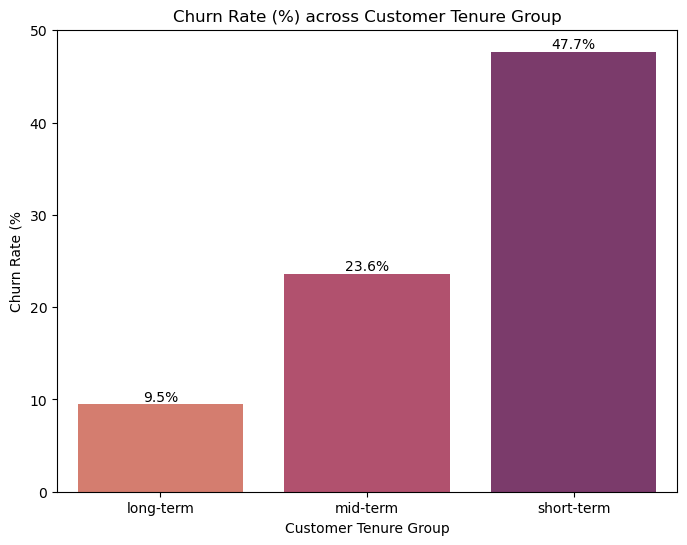

In [11]:
# Data Visualization

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=cohort_analysis,
    x='TenureGroup',
    y='ChurnRate',
    palette='flare',
    hue='TenureGroup'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.xlabel('Customer Tenure Group')
plt.ylabel('Churn Rate (%')
plt.title('Churn Rate (%) across Customer Tenure Group')
plt.show()

# This shows that the business is losing almost half of its accounts within their first 12 months.

In [12]:
autopay_summary = df.groupby('IsAutomatic')['Churn'].mean() * 100
print(f"Churn percentage in Manual Billing: {autopay_summary[0]:.2f}%")
print(f"Churn percentage in Automatic Billing: {autopay_summary[1]:.2f}%\n\n")

# Forcing a customer to manually authorize their bill every 30 days creates an accidental,
# repetitive emotional choice-point to reconsider the platform's value. Automation acts as a 
# powerful behavioral retention barrier.

Churn percentage in Manual Billing: 34.74%
Churn percentage in Automatic Billing: 16.00%




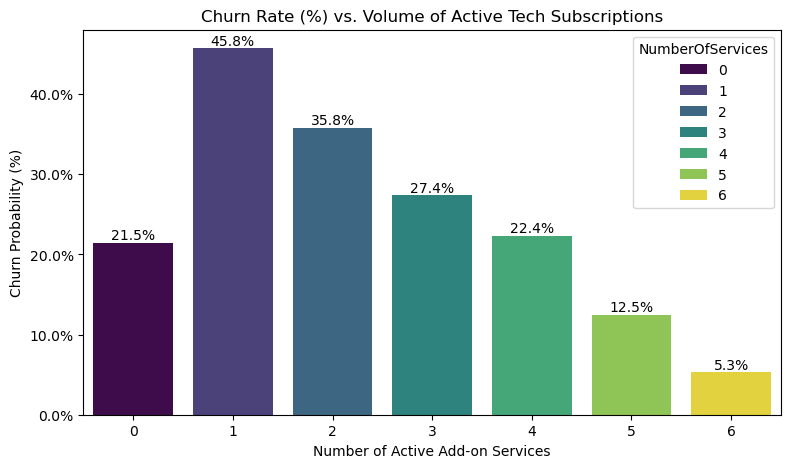

In [13]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df,
    x='NumberOfServices',
    y='Churn',
    errorbar=None,
    palette='viridis',
    hue='NumberOfServices'
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
for container in ax.containers:
    ax.bar_label(container,labels=[f'{v.get_height()*100:.1f}%'for v in container])
plt.title('Churn Rate (%) vs. Volume of Active Tech Subscriptions')
plt.ylabel('Churn Probability (%)')
plt.xlabel('Number of Active Add-on Services')
plt.show()

# Customers using zero add-on services show an extreme churn rate of over 40%, whereas users who
# attach 3 or more add-on utilities show drop-offs close to negligible figures.

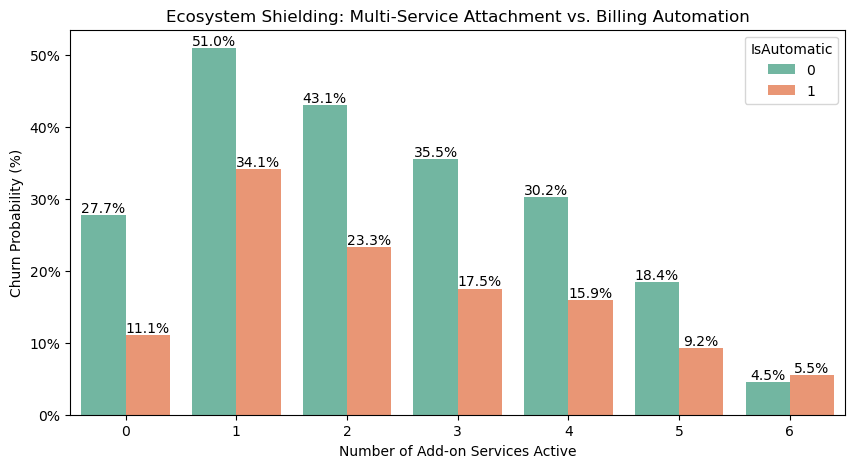

In [14]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df,
    x='NumberOfServices',
    y='Churn',
    hue='IsAutomatic',
    errorbar=None,
    palette='Set2'
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
for container in ax.containers:
    ax.bar_label(container,labels=[f'{v.get_height()*100:.1f}%'for v in container])
plt.title('Ecosystem Shielding: Multi-Service Attachment vs. Billing Automation')
plt.ylabel('Churn Probability (%)')
plt.xlabel('Number of Add-on Services Active')
plt.show()

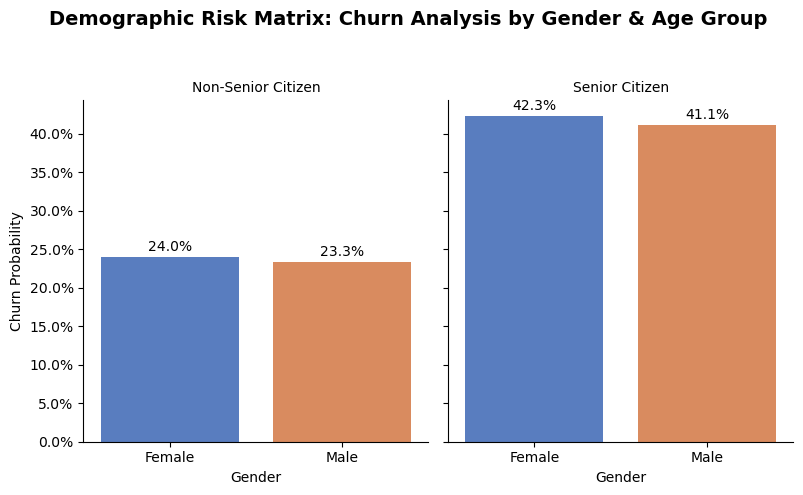

In [15]:
df['SeniorLabel'] = df['SeniorCitizen'].map({
    0: 'Non-Senior Citizen',
    1: 'Senior Citizen'
})
fig = sns.catplot(
    data=df, 
    x='gender', 
    y='Churn', 
    col='SeniorLabel', 
    kind='bar', 
    errorbar=None, 
    palette='muted',
    height=5, 
    aspect=0.8,
    hue='gender',
    legend=False
)

fig.set_axis_labels("Gender","Churn Probability")
fig.set_titles("{col_name}")

for ax in fig.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f'{v.get_height()*100:.1f}%'
                for v in container
            ],
            padding=2
        )

plt.subplots_adjust(top=0.8)
fig.fig.suptitle(
    'Demographic Risk Matrix: Churn Analysis by Gender & Age Group',
    fontsize=14,
    weight='bold'
)
plt.show()

# Gender variance plays almost no statistical role in contract cancellation, but user age does.

In [16]:
# Conclusion:
# The project successfully diagnosed historical customer behavior, isolated critical attrition drivers, and mapped out customer lifecycle retention trends. 
# By engineering key metrics like billing automation paths (IsAutomatic) and system entanglement indices (NumberOfServices), the analysis proved that short-term onboarding phases represent the highest vulnerability vector for recurring revenue bleeding. 
# These data-driven insights translate directly into high-impact, programmatic retention workflows, empowering business stakeholders and product managers to replace static, generalized retention methods with hyper-targeted, high-ROI client stabilization strategies.